<a href="https://colab.research.google.com/github/Dhrish75/Deep-Learning-Projects/blob/main/STOCK_MARKET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Path to dataset files: /kaggle/input/heart-failure-clinical-data


In [ ]:
from zipfile import ZipFile
import os

with ZipFile('/content/candlestick_patterns2.zip', 'r') as zip_ref:
    zip_ref.extractall('candlestick_pattern')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import os

# Data Augmentation

In [ ]:
img_size = (224, 224)
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

base_dir = '/content/candlestick_pattern_split'

train_gen = train_datagen.flow_from_directory(
    f'{base_dir}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_directory(
    f'{base_dir}/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_val_datagen.flow_from_directory(
    f'{base_dir}/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_gen.class_indices)


Found 1058 images belonging to 4 classes.
Found 303 images belonging to 4 classes.
Found 229 images belonging to 4 classes.
Classes: {'bearish_engulfing1': 0, 'bullish_engulfing1': 1, 'double_top': 2, 'shooting_star1': 3}


# Model And Training

In [ ]:
# Automatically get class labels from the generator
class_labels = list(train_gen.class_indices.keys())
num_classes = len(class_labels)

print("Detected Classes:", class_labels)

# Define CNN model
model = Sequential([
    # Conv Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=img_size + (3,)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 4
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Detected Classes: ['bearish_engulfing1', 'bullish_engulfing1', 'double_top', 'shooting_star1']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,804 (37.49 MB)

 Trainable params: 9,827,844 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    min_delta=0.001
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001
)

# Fit the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    batch_size=batch_size, # Use the defined batch_size variable
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.5860 - loss: 4.2732 - val_accuracy: 0.2970 - val_loss: 4.8807 - learning_rate: 5.0000e-04
Epoch 2/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.7906 - loss: 1.0706 - val_accuracy: 0.5281 - val_loss: 1.4320 - learning_rate: 5.0000e-04
Epoch 3/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.8278 - loss: 0.5733 - val_accuracy: 0.5842 - val_loss: 1.1825 - learning_rate: 5.0000e-04
Epoch 4/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.8178 - loss: 0.5429 - val_accuracy: 0.6436 - val_loss: 0.6033 - learning_rate: 5.0000e-04
Epoch 5/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - accuracy: 0.8734 - loss: 0.3077 - val_accuracy: 0.8713 - val_loss: 0.3950 - learning_rate: 5.0000e-04
Epoch 6/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.8978 - loss: 0.4028 - val_accuracy: 0.9010 - val_loss: 0.2886 - learning_rate: 5.0000e-04
Epoch 7/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.9080 - loss:

In [ ]:
model.save("5_layer_candlesticks.h5")

In [ ]:
model = tf.keras.models.load_model("5_layer_candlestick_optimized.h5")

class_labels = ['bearish_engulfing', 'bullish_engulfing', 'double_top', 'shooting_star']

# Evaluate Graph

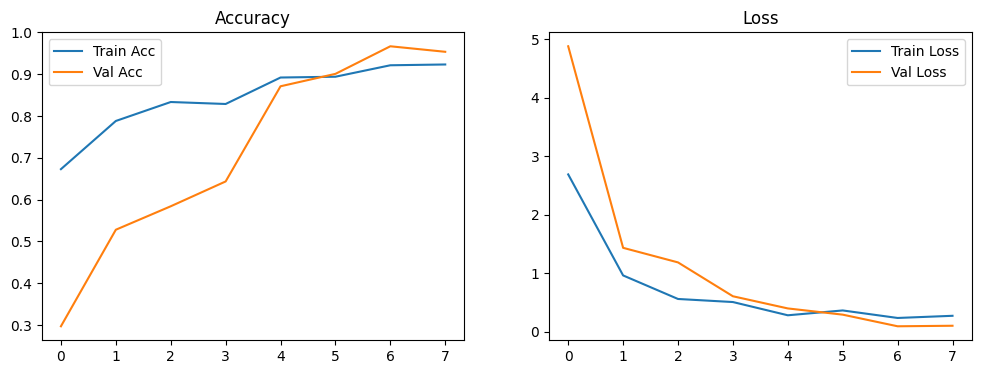

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()


# Classify and testing

In [ ]:
from tensorflow.keras.models import load_model

# Load your previously saved model
model = load_model('/content/5_layer_candlesticks.h5')
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")


15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 743ms/step - accuracy: 0.8995 - loss: 0.1581
Test Accuracy: 95.63%


In [ ]:
# Class names from your training generator
class_labels = list(train_gen.class_indices.keys())

def predict_pattern(img_path, actual_label=None):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Show image and result
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    title = f"Predicted: {predicted_class} ({confidence:.2f}%)"
    if actual_label:
        title += f"\nActual: {actual_label}"
    plt.title(title, fontsize=12)
    plt.show()

    return predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


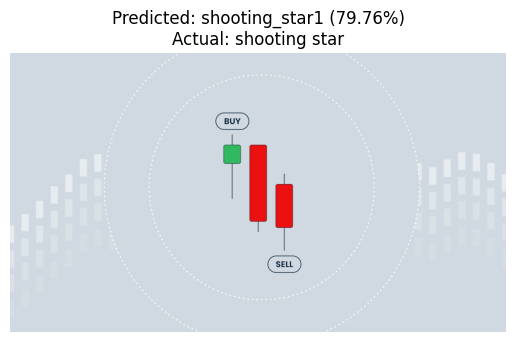

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


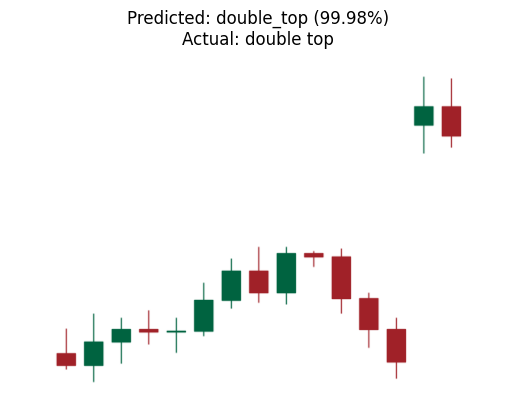

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


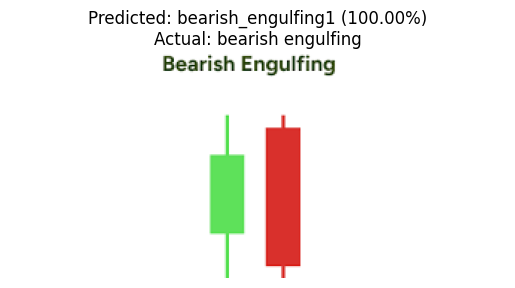

'bearish_engulfing1'

In [ ]:
predict_pattern("/content/shooting star.jpg", actual_label="shooting star")

predict_pattern("/content/double_top_0151.png", actual_label="double top")

predict_pattern("/content/bearish_engulfing.png", actual_label="bearish engulfing")
